/tmp/ipython-input-1542594024.py:15: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url)


--- 준비된 데이터 (상위 5행) ---
country     Korea  Canada  Greece  Japan  US
date                                        
2020-01-22      1       0       0      2   1
2020-01-23      0       2       0      0   0
2020-01-24      1       1       0      0   1
2020-01-25      0       0       0      0   0
2020-01-26      1       0       0      2   3


/usr/local/lib/python3.12/dist-packages/causalimpact/main.py:603: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  if not data.applymap(np.isreal).values.all():
/usr/local/lib/python3.12/dist-packages/causalimpact/main.py:302: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  self.mu_sig = (mu[0], sig[0])
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method lbfgs is: m, pgtol, factr, maxfun, epsilon, approx_grad, boun


--- 분석 요약 (Summary) ---
Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    134.02             8443.0
Prediction (s.d.)         69118.69 (11.38)   4354477.47 (716.63)
95% CI                    [69096.33, 69140.92][4353068.74, 4355877.89]

Absolute effect (s.d.)    -68984.67 (11.38)  -4346034.47 (716.63)
95% CI                    [-69006.9, -68962.31][-4347434.89, -4344625.74]

Relative effect (s.d.)    -99.81% (0.02%)    -99.81% (0.02%)
95% CI                    [-99.84%, -99.77%] [-99.84%, -99.77%]

Posterior tail-area probability p: 0.0
Posterior prob. of a causal effect: 100.0%

For more details run the command: print(impact.summary('report'))

--- 상세 리포트 (Report) ---
Analysis report {CausalImpact}


During the post-intervention period, the response variable had
an average value of approx. 134.02. By contrast, in the absence of an
intervention, we would have expected an average response of 69118.69.
The 95% interval 

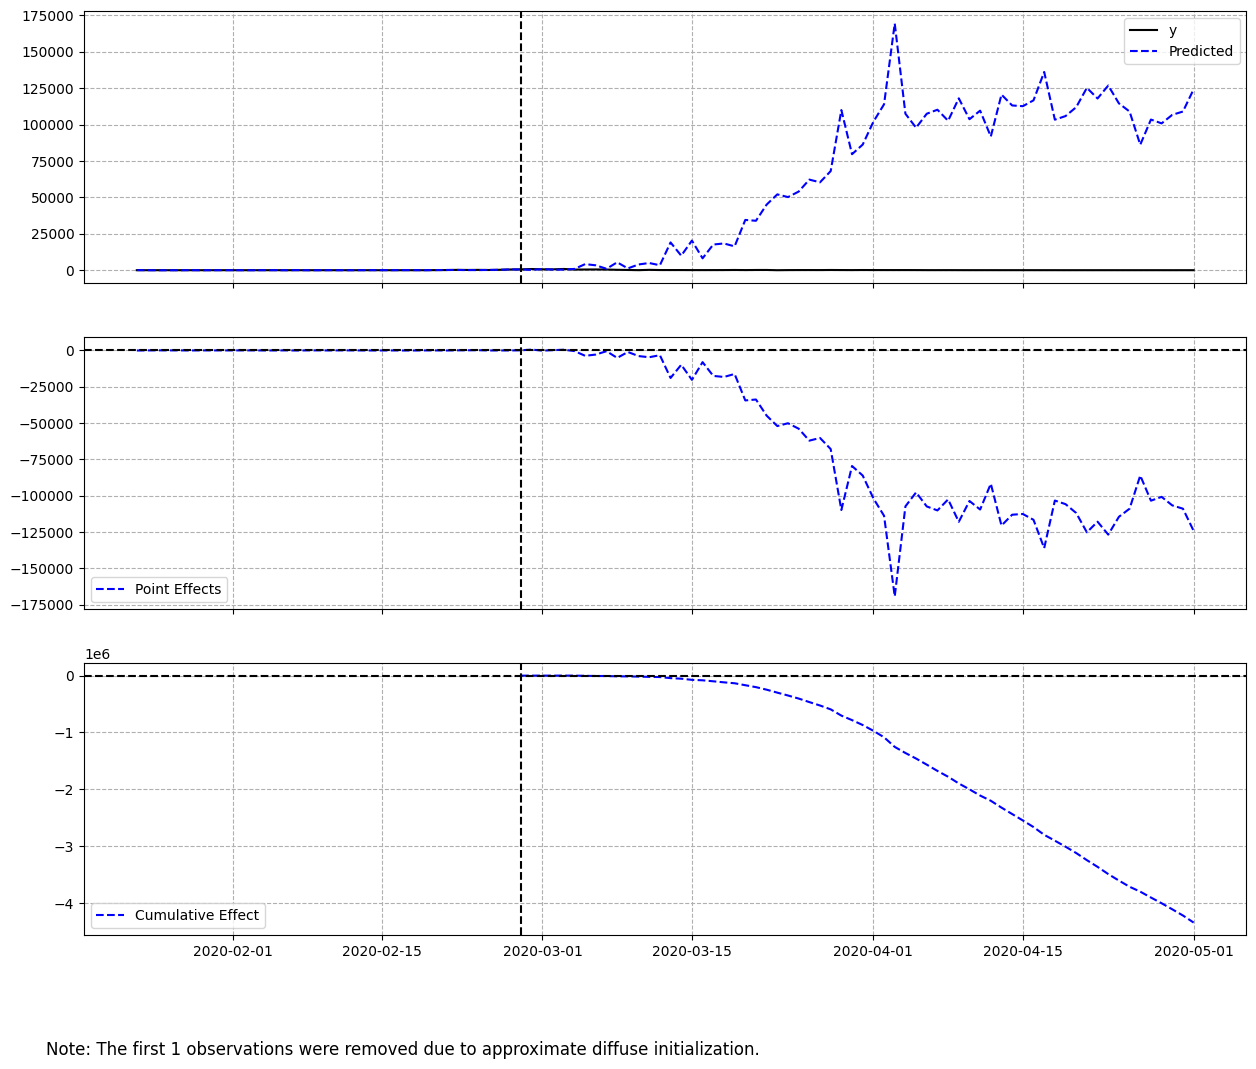

In [1]:
!pip install pycausalimpact

import pandas as pd
from causalimpact import CausalImpact
import matplotlib.pyplot as plt

# R 패키지에서 사용하는 원본 데이터셋(JHU 데이터)을 불러옵니다.
url = "https://raw.githubusercontent.com/RamiKrispin/coronavirus/master/csv/coronavirus.csv"
df = pd.read_csv(url)

# 날짜 형식 변환
df['date'] = pd.to_datetime(df['date'])

# 분석 기간 및 국가 설정
start_date = '2020-01-22'
treat_date = '2020-02-28' # 개입 시점 (거리두기 시작 등)
end_date = '2020-05-01'

target_countries = ['Korea, South', 'Canada', 'Greece', 'US', 'Japan']

# 데이터 필터링 (확진자 & 특정 국가 & 기간)
df_filtered = df[
    (df['type'] == 'confirmed') &
    (df['country'].isin(target_countries)) &
    (df['date'] >= start_date) &
    (df['date'] <= end_date)
].copy()

# 국가명 변경 ('Korea, South' -> 'Korea') : R 코드와 동일하게
df_filtered['country'] = df_filtered['country'].replace('Korea, South', 'Korea')

# 날짜별, 국가별 확진자 수 합계 (Group by)
df_grouped = df_filtered.groupby(['date', 'country'])['cases'].sum().reset_index()


df_final = df_grouped.pivot(index='date', columns='country', values='cases')
df_final = df_final.fillna(0)
cols = ['Korea'] + [c for c in df_final.columns if c != 'Korea']
df_final = df_final[cols]
print("--- 준비된 데이터 (상위 5행) ---")
print(df_final.head())

# 4. CausalImpact 실행
# 사전(Pre) 및 사후(Post) 기간 설정
pre_period = [start_date, treat_date]
post_period = [pd.to_datetime(treat_date) + pd.Timedelta(days=1), end_date]

# 모델 실행
ci = CausalImpact(df_final, pre_period, post_period)

# 5. 결과 리포트 및 시각화
# (1) 요약 통계 출력
print("\n--- 분석 요약 (Summary) ---")
print(ci.summary())
# (2) 상세 리포트 출력
print("\n--- 상세 리포트 (Report) ---")
print(ci.summary(output='report'))
# (3) 그래프 그리기
# R의 plot(causal_impact)와 동일
ci.plot()

In [ ]:
ci = CausalImpact(df_final, pre_period, post_period)
ci.summary()